# 07 — LJ early latent slope and p-ratio

Train a reconstruction-only autoencoder with a 2D latent, correlate p-ratio with the initial latent and its early slope, and separately test a learned latent propagator. Every LJ frame is represented on-the-fly as a directed fully connected graph. The AE itself still has no MI loss, rollout loss, or supervised p-ratio head.

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from lss.latent.capacity import evaluate_experiment
from lss.latent.experiment import ground_truth_p_ratio, run_latent_experiment, seed_everything
from lss.latent.training import encode_frame_latent
from lss.utils import resolve_device
DEVICE = resolve_device('auto')

/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Settings

Choose `TRAIN_COUNT` as desired. `EARLY_FRAMES=5` fits the slope using frames 0–4 only. The AE and propagator train on only the first 100 frames/transitions of each 200-frame trajectory; rollout is evaluated at step 150. `EDGE_MODE='complete'` constructs every directed pair with periodic reference/current geometry and preserves stored elastic coefficients.

In [2]:
TRAIN_COUNT = 20          # set the number of training networks
LATENT_DIM = 2
EDGE_MODE = 'complete'
AE_TRAIN_FRAMES = 100
DYN_TRAIN_TRANSITIONS = 100
ROLLOUT_SCATTER_STEP = 150
ROLLOUT_EVAL_SIMS = 20     # quick evaluation during the training cell
EARLY_FRAMES = 5           # use only the first 3, 5, or 10 frames
MAX_TEST_NETWORKS = 300  # set to None to evaluate every held-out network
FORCE_TRAIN = True
SEED = 345345

DATA = PROJECT_ROOT / 'data' / 'lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt'
OUTPUT = PROJECT_ROOT / 'notebooks' / 'results' / '15_lj_early_slope_train1_2'
CACHE = OUTPUT / 'models' / f'lj_rollout2d_{EDGE_MODE}_train{TRAIN_COUNT}_frames{AE_TRAIN_FRAMES}_seed{SEED}.pt'
OUTPUT.mkdir(parents=True, exist_ok=True)
CACHE.parent.mkdir(parents=True, exist_ok=True)
assert DATA.exists(), DATA

## Train the reconstruction-only 2D autoencoder and latent propagator

Only this cell trains. The AE loss remains reconstruction-only; the propagator is fitted afterward on encoded transitions. Re-running loads the joint cache unless `FORCE_TRAIN=True`.

In [3]:
cfg = {
    'dataset_name': 'lj_noisy', 'split_seed': SEED, 'device': str(DEVICE),
    'pos_dim': 2, 'batch_graphs': 1, 'frame_skip': 1,
    'latent_dim': LATENT_DIM, 'latent_tokens': 32, 'hidden_size': 96,
    'autoencoder_model': 'attention', 'edge_feature_dim': 13, 'edge_mode': EDGE_MODE,
    'ae_target_mode': 'normalized_delta', 'node_feature_mode': 'normalized_delta',
    'ae_max_train_frames_per_sim': AE_TRAIN_FRAMES,
    'dyn_max_train_transitions_per_sim': DYN_TRAIN_TRANSITIONS,
    'ae_max_epochs': 100, 'ae_patience': 10,
    'ae_lr': 5e-5, 'ae_weight_decay': 1e-5, 'early_stop_min_delta': 1e-5,
    'dyn_max_epochs': 80, 'dyn_patience': 10, 'dyn_lr': 3e-5, 'dyn_weight_decay': 1e-4,
    'propagator_use_static_context': True, 'graph_context_dim': 16,
    'propagator_model': 'delta_mlp', 'propagator_loss': 'delta',
    'rollout_steps_grid': [25, 50, 100, ROLLOUT_SCATTER_STEP],
    'rollout_eval_max_sims_per_split': ROLLOUT_EVAL_SIMS,
    'should_rollout': True, 'should_train_propagator': True,
    'force_train': FORCE_TRAIN, 'cache_path': str(CACHE),
    'model_seed': SEED, 'repeat_idx': 1,
    'temperature_pratio_estimator': 'robust',
    'temperature_pratio_min_fit_frames': 8,
    'temperature_pratio_min_driven_strain_range': 1e-3,
    'temperature_pratio_smooth_window': 5,
}
source = {
    'dataset_name': 'lj_noisy', 'source_name': 'LJ noisy',
    'label': f'LJ reconstruction-only AE, train={TRAIN_COUNT}', 'path': str(DATA),
    'dataset_mixture': [{'name': 'lj_noisy', 'label': 'LJ noisy', 'path': str(DATA),
                         'train_count': TRAIN_COUNT, 'val_count': 20}],
    'target_mode': 'normalized_delta', 'ae_target_mode': 'normalized_delta',
    'node_feature_mode': 'normalized_delta', 'edge_mode': EDGE_MODE, 'latent_dim': LATENT_DIM,
    'latent_tokens': 32, 'hidden_size': 96, 'autoencoder_model': 'attention',
    'edge_feature_dim': 13, 'ae_max_train_frames_per_sim': AE_TRAIN_FRAMES,
    'dyn_max_train_transitions_per_sim': DYN_TRAIN_TRANSITIONS,
    'ae_max_epochs': 100, 'ae_patience': 10,
    'dyn_max_epochs': 80, 'dyn_patience': 10,
    'dyn_lr': 3e-5, 'dyn_weight_decay': 1e-4,
}
seed_everything(SEED)
result = run_latent_experiment(source, cfg, device=DEVICE)
result['ae_history'].tail()


=== LJ reconstruction-only AE, train=20 ===
  source                                                                                                 path  total  train  reserved_train_pool  val  test
lj_noisy /home/alexz/Documents/course_project/data/lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt    200     20                   20   20   160
autoencoder
ae 0001 train=0.375743 val=0.32507 stale=0
ae 0002 train=0.276327 val=0.314829 stale=0
ae 0003 train=0.269442 val=0.313378 stale=0
ae 0004 train=0.265311 val=0.306262 stale=0
ae 0005 train=0.262359 val=0.303981 stale=0
ae 0008 train=0.252346 val=0.303254 stale=0
ae 0009 train=0.247915 val=0.300909 stale=0
ae 0010 train=0.244723 val=0.30314 stale=1
ae early stop at epoch 0019; best_epoch=0009 best_val=0.300909
latent propagator: objective=one_step step_stride=1 horizons=None train_rows=2000 val_rows=2000
propagator 0001 train=0.687496 val=0.274097 stale=0
propagator 0010 train=0.10537 val=0.433231 stale=9
propagator early st

,epoch,train_objective,val_objective,train_mse_norm,val_mse_norm,dataset,latent_dim,target_mode,hidden_size
14,15,0.226601,0.341455,0.226601,0.341455,"LJ reconstruction-only AE, train=20",2,normalized_delta,96
15,16,0.220977,0.345951,0.220977,0.345951,"LJ reconstruction-only AE, train=20",2,normalized_delta,96
16,17,0.215941,0.370477,0.215941,0.370477,"LJ reconstruction-only AE, train=20",2,normalized_delta,96
17,18,0.209945,0.367289,0.209945,0.367289,"LJ reconstruction-only AE, train=20",2,normalized_delta,96
18,19,0.205270,0.385846,0.205270,0.385846,"LJ reconstruction-only AE, train=20",2,normalized_delta,96


## Encode only the early frames and calculate the slope

In [4]:
def early_slope(sequence):
    time = np.arange(len(sequence), dtype=float)
    time -= time.mean()
    return (time[:, None] * sequence).sum(0) / (time ** 2).sum()

test_sims = result['test_data'] if MAX_TEST_NETWORKS is None else result['test_data'][:MAX_TEST_NETWORKS]
rows = []
with torch.no_grad():
    for sim_index, sim in enumerate(test_sims):
        n_early = min(EARLY_FRAMES, len(sim))
        if n_early < 2:
            continue  # at least two frames are required to define a slope
        latent = np.stack([
            encode_frame_latent(
                result['ae'], sim, frame, pos_dim=2,
                node_feature_mode='normalized_delta',
                normalizers=result['normalizers'], device=DEVICE, edge_mode=EDGE_MODE,
            ).cpu().numpy()
            for frame in range(n_early)
        ])
        slope = early_slope(latent)
        rows.append({
            'sim_index': sim_index,
            'frames_used': n_early,
            'p_ratio': ground_truth_p_ratio(sim, dataset_name='lj_noisy', cfg=cfg),
            'initial_z0': latent[0, 0], 'initial_z1': latent[0, 1],
            'slope_z0': slope[0], 'slope_z1': slope[1],
            'slope_speed': np.linalg.norm(slope),
        })
early = pd.DataFrame(rows).dropna()
early.head()

,sim_index,frames_used,p_ratio,initial_z0,initial_z1,slope_z0,slope_z1,slope_speed
0,0,5,0.507441,-1.313302,2.104138,0.016006,0.069758,0.071570
1,1,5,0.452067,-1.160993,2.270686,0.005154,0.061052,0.061269
2,2,5,0.225563,-1.127282,2.282794,0.014620,0.063159,0.064829
3,3,5,0.245885,-0.716508,2.792130,0.008308,0.056902,0.057505
4,4,5,0.641112,-1.068123,2.563787,0.002320,0.059689,0.059735


## Initial-latent and early-slope correlations

`initial_z0` and `initial_z1` are the latent coordinates of frame 0; the slopes use only the first `EARLY_FRAMES` frames. The signs and ordering of `z0` and `z1` are arbitrary, so compare absolute correlations when repeating the training with another seed.

In [5]:
correlations = pd.DataFrame({
    'feature': ['initial_z0', 'initial_z1', 'slope_z0', 'slope_z1', 'slope_speed'],
    'pearson_r_with_p_ratio': [early[col].corr(early.p_ratio) for col in ['initial_z0','initial_z1','slope_z0','slope_z1','slope_speed']],
})
display(correlations.round(4))
early.to_csv(OUTPUT / f'{EDGE_MODE}_early_slopes_train{TRAIN_COUNT}_first{EARLY_FRAMES}.csv', index=False)
correlations.to_csv(OUTPUT / f'{EDGE_MODE}_latent_correlations_train{TRAIN_COUNT}_first{EARLY_FRAMES}.csv', index=False)

,feature,pearson_r_with_p_ratio
0,initial_z0,-0.0267
1,initial_z1,-0.0415
2,slope_z0,-0.6253
3,slope_z1,-0.1166
4,slope_speed,-0.1926


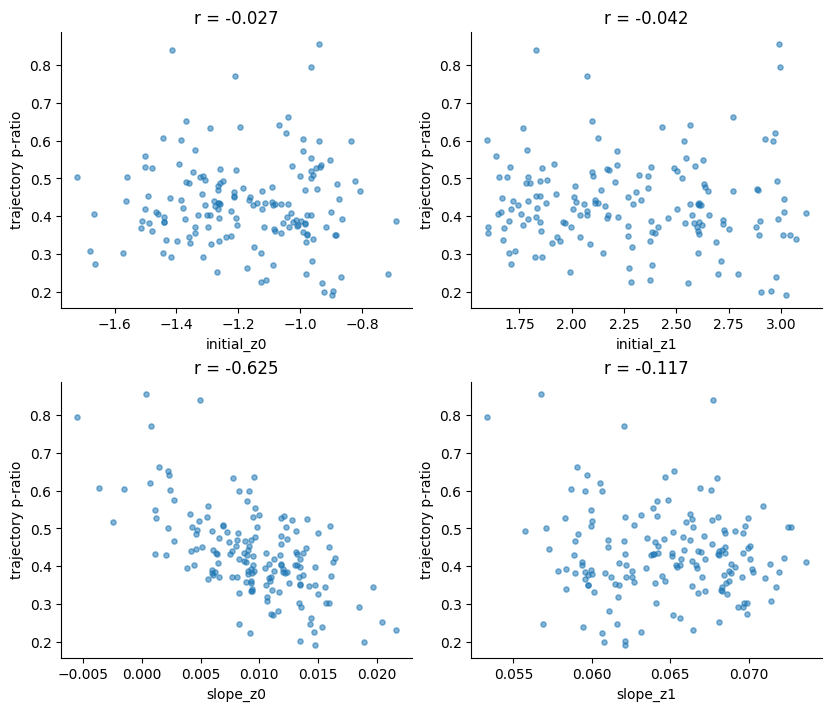

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(8.2, 7.0), constrained_layout=True)
for ax, column in zip(axes.flat, ['initial_z0', 'initial_z1', 'slope_z0', 'slope_z1']):
    r = early[column].corr(early.p_ratio)
    ax.scatter(early[column], early.p_ratio, s=14, alpha=.55)
    ax.set(xlabel=column, ylabel='trajectory p-ratio', title=f'r = {r:.3f}')
    ax.spines[['top','right']].set_visible(False)
plt.show()

## Latent rollout test

The training cell uses only 20 trajectories per split for quick rollout diagnostics. This final cell performs a separate test-only evaluation at step 150 on every held-out network (175 points with the current 5-train/20-validation split).

In [7]:
final_test_cfg = {**cfg,
                  'rollout_eval_max_sims_per_split': None,
                  'rollout_steps_grid': [ROLLOUT_SCATTER_STEP]}
result = evaluate_experiment(result, final_test_cfg, device=DEVICE)
rollout = result['rollout_stats'].copy()
display_cols = ['split', 'rollout_steps', 'p_ratio_r2']
display(rollout[display_cols].round(4))
rollout.to_csv(OUTPUT / f'{EDGE_MODE}_rollout_train{TRAIN_COUNT}_seed{SEED}.csv', index=False)
result['rollout_rows'].to_csv(OUTPUT / f'{EDGE_MODE}_rollout_predictions_train{TRAIN_COUNT}_seed{SEED}.csv', index=False)

,split,rollout_steps,p_ratio_r2
0,train,25,0.0258
1,train,50,0.0554
2,train,100,-0.2211
3,train,150,-0.5877
4,val,25,-0.0920
5,val,50,-0.1725
6,val,100,-0.2906
7,val,150,-0.4890
8,test,25,-0.2035
9,test,50,-0.1414


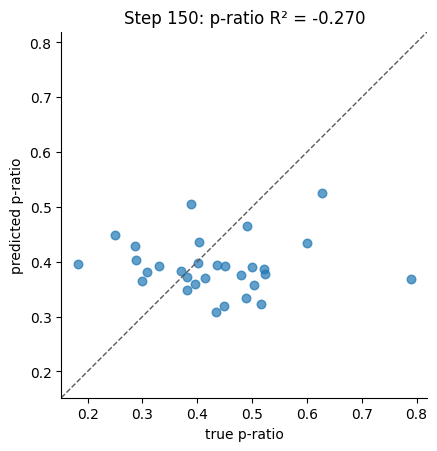

In [8]:
parity = result['rollout_rows'].query("split == 'test' and rollout_steps == @ROLLOUT_SCATTER_STEP").dropna(subset=['true_p_ratio', 'pred_p_ratio'])
score = rollout.query("split == 'test' and rollout_steps == @ROLLOUT_SCATTER_STEP")['p_ratio_r2'].iloc[0]
limits = [min(parity.true_p_ratio.min(), parity.pred_p_ratio.min()), max(parity.true_p_ratio.max(), parity.pred_p_ratio.max())]
padding = .05 * max(limits[1] - limits[0], 1e-6)
limits = [limits[0] - padding, limits[1] + padding]
fig, ax = plt.subplots(figsize=(4.8, 4.4), constrained_layout=True)
ax.scatter(parity.true_p_ratio, parity.pred_p_ratio, s=38, alpha=.7)
ax.plot(limits, limits, color='.35', ls='--', lw=1, label='ideal')
ax.set(xlim=limits, ylim=limits, xlabel='true p-ratio', ylabel='predicted p-ratio',
       title=f'Step {ROLLOUT_SCATTER_STEP}: p-ratio R² = {score:.3f}')
ax.set_aspect('equal', adjustable='box')
ax.spines[['top', 'right']].set_visible(False)
plt.show()